# Anteriormente, em Manipulação de Dados...

In [97]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [98]:
ARQUIVO_DADOS = 'churn_clientes.csv'

df_churn = pd.read_csv(ARQUIVO_DADOS)
df_churn.head()

,id_cliente,genero,idoso,tem_parceiro,tem_dependentes,meses_na_empresa,servico_telefone,multiplas_linhas,servico_internet,servico_seguranca,...,servico_protecao_equipamento,servico_suporte_tecnico,streaming_tv,streaming_filmes,contrato,fatura_digital,forma_pagamento,valor_mensal,total_gasto,churn
0,7590-VHVEG,Feminino,Não,Sim,Não,1,Não,Não,DSL,Não,...,Não,Não,Não,Não,Mensal,Sim,Boleto,29.85,29.85,Não
1,5575-GNVDE,Masculino,Não,Não,Não,34,Sim,Não,DSL,Sim,...,Sim,Não,Não,Não,Anual,Não,Cheque,56.95,1889.50,Não
2,3668-QPYBK,Masculino,Não,Não,Não,2,Sim,Não,DSL,Sim,...,Não,Não,Não,Não,Mensal,Sim,Cheque,53.85,108.15,Sim
3,7795-CFOCW,Masculino,Não,Não,Não,45,Não,Não,DSL,Sim,...,Sim,Sim,Não,Não,Anual,Não,Transferencia,42.30,1840.75,Não
4,9237-HQITU,Feminino,Não,Não,Não,2,Sim,Não,Fibra optica,Não,...,Não,Não,Não,Não,Mensal,Sim,Boleto,70.70,151.65,Sim


In [99]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_cliente                    7043 non-null   object 
 1   genero                        7043 non-null   object 
 2   idoso                         7043 non-null   object 
 3   tem_parceiro                  7043 non-null   object 
 4   tem_dependentes               7043 non-null   object 
 5   meses_na_empresa              7043 non-null   int64  
 6   servico_telefone              7043 non-null   object 
 7   multiplas_linhas              7043 non-null   object 
 8   servico_internet              7043 non-null   object 
 9   servico_seguranca             7043 non-null   object 
 10  servico_backup                7043 non-null   object 
 11  servico_protecao_equipamento  7043 non-null   object 
 12  servico_suporte_tecnico       7043 non-null   object 
 13  str

In [100]:
df_churn.describe()

,meses_na_empresa,valor_mensal,total_gasto
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928
std,24.559481,30.090047,2265.270398
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [101]:
df_churn.describe(exclude='number')

,id_cliente,genero,idoso,tem_parceiro,tem_dependentes,servico_telefone,multiplas_linhas,servico_internet,servico_seguranca,servico_backup,servico_protecao_equipamento,servico_suporte_tecnico,streaming_tv,streaming_filmes,contrato,fatura_digital,forma_pagamento,churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,2,2,3,2,2,2,2,2,2,3,2,4,2
top,7590-VHVEG,Masculino,Não,Não,Não,Sim,Não,Fibra optica,Não,Não,Não,Não,Não,Não,Mensal,Sim,Boleto,Não
freq,1,3555,5901,3641,4933,6361,4072,3096,5024,4614,4621,4999,4336,4311,3875,4171,2365,5174


In [102]:
df_churn['churn'].value_counts()

churn
Não    5174
Sim    1869
Name: count, dtype: int64

In [103]:
df_churn['churn'].value_counts(normalize=True)*100

churn
Não    73.463013
Sim    26.536987
Name: proportion, dtype: float64

In [104]:
df_churn = df_churn.drop(columns='id_cliente', axis=1)
df_churn.head()

,genero,idoso,tem_parceiro,tem_dependentes,meses_na_empresa,servico_telefone,multiplas_linhas,servico_internet,servico_seguranca,servico_backup,servico_protecao_equipamento,servico_suporte_tecnico,streaming_tv,streaming_filmes,contrato,fatura_digital,forma_pagamento,valor_mensal,total_gasto,churn
0,Feminino,Não,Sim,Não,1,Não,Não,DSL,Não,Sim,Não,Não,Não,Não,Mensal,Sim,Boleto,29.85,29.85,Não
1,Masculino,Não,Não,Não,34,Sim,Não,DSL,Sim,Não,Sim,Não,Não,Não,Anual,Não,Cheque,56.95,1889.50,Não
2,Masculino,Não,Não,Não,2,Sim,Não,DSL,Sim,Sim,Não,Não,Não,Não,Mensal,Sim,Cheque,53.85,108.15,Sim
3,Masculino,Não,Não,Não,45,Não,Não,DSL,Sim,Não,Sim,Sim,Não,Não,Anual,Não,Transferencia,42.30,1840.75,Não
4,Feminino,Não,Não,Não,2,Sim,Não,Fibra optica,Não,Não,Não,Não,Não,Não,Mensal,Sim,Boleto,70.70,151.65,Sim


In [105]:
colunas_numericas = df_churn.select_dtypes(include='number').columns
print(colunas_numericas)

Index(['meses_na_empresa', 'valor_mensal', 'total_gasto'], dtype='object')


In [106]:
colunas_categoricas = df_churn.select_dtypes(exclude='number').columns
print(colunas_categoricas)

Index(['genero', 'idoso', 'tem_parceiro', 'tem_dependentes',
       'servico_telefone', 'multiplas_linhas', 'servico_internet',
       'servico_seguranca', 'servico_backup', 'servico_protecao_equipamento',
       'servico_suporte_tecnico', 'streaming_tv', 'streaming_filmes',
       'contrato', 'fatura_digital', 'forma_pagamento', 'churn'],
      dtype='object')


In [107]:
colunas_categoricas = colunas_categoricas.drop('churn')
colunas_categoricas

Index(['genero', 'idoso', 'tem_parceiro', 'tem_dependentes',
       'servico_telefone', 'multiplas_linhas', 'servico_internet',
       'servico_seguranca', 'servico_backup', 'servico_protecao_equipamento',
       'servico_suporte_tecnico', 'streaming_tv', 'streaming_filmes',
       'contrato', 'fatura_digital', 'forma_pagamento'],
      dtype='object')

# Seaborn, Lidando com Variáveis categóricas

Após o tratamento de colunas numéricas e categóricas da aula de análise de dados com pandas, cruzaremos nossa variável alvo (churn) com as variáveis categóricas em uma matriz de colunas gráficas. O resultado final esperado está nos gráficos abaixo:

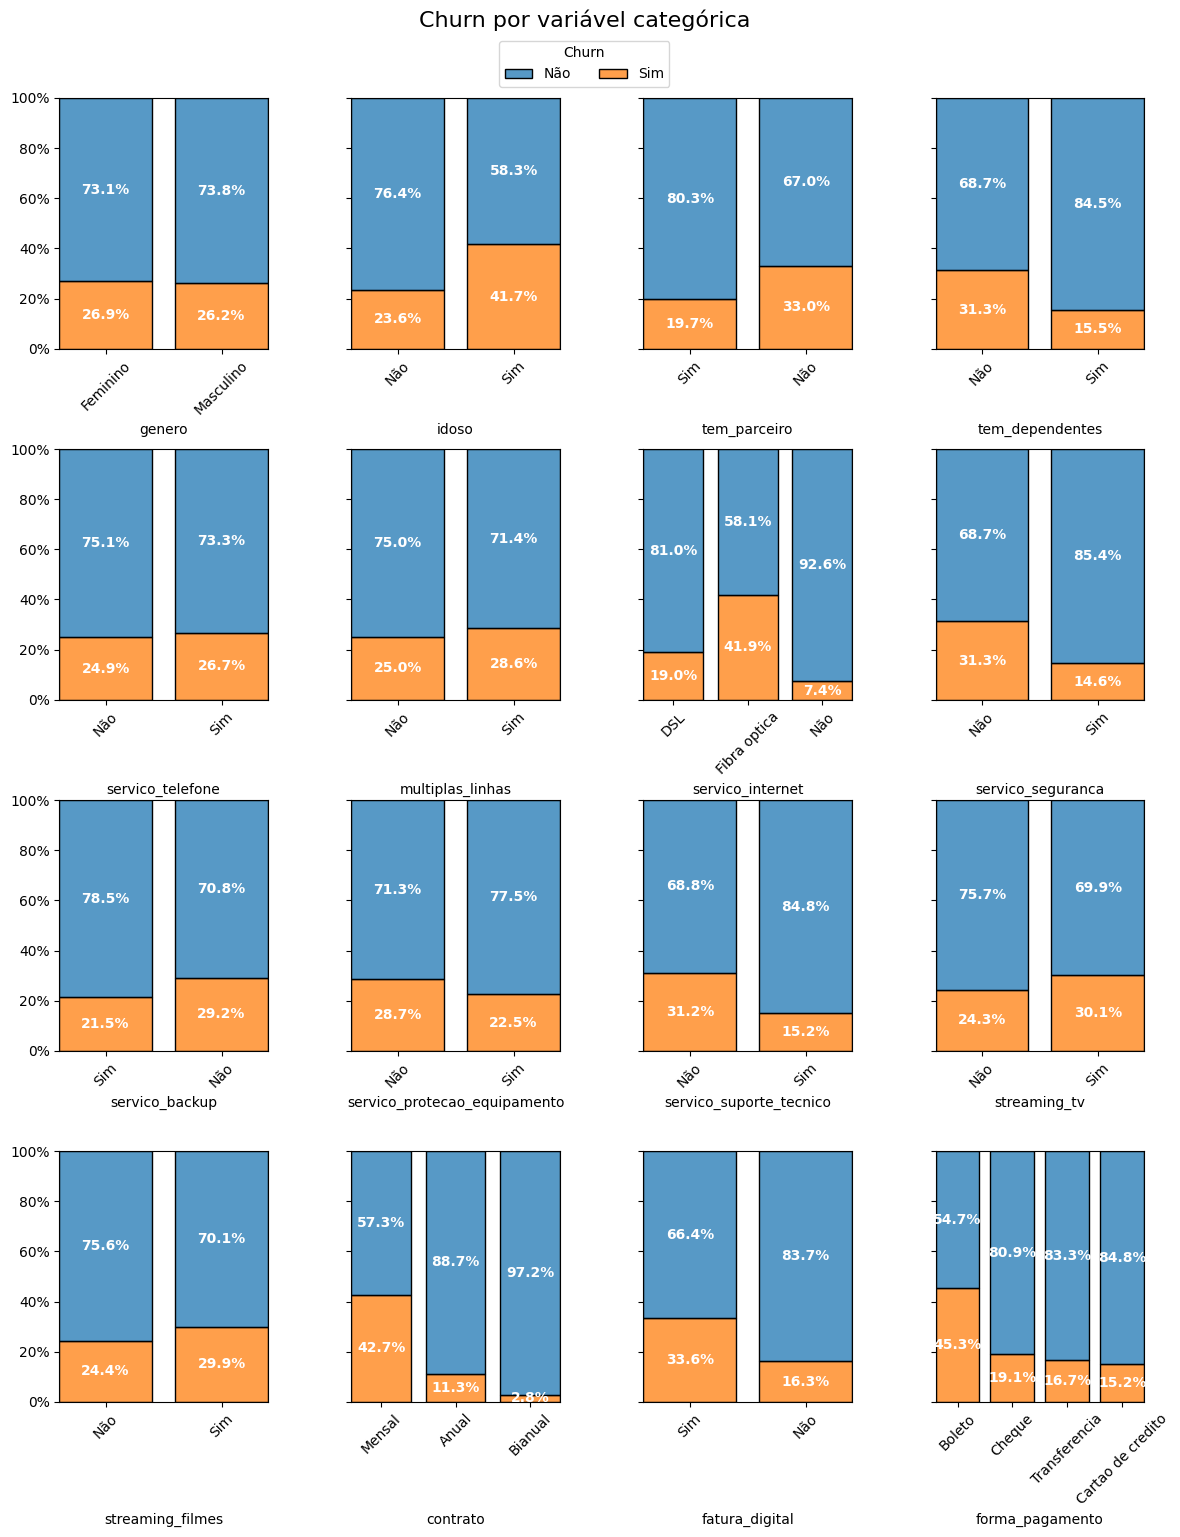

## Resultado:
1. Vários gráficos (um por variável categórica)
2. Cada gráfico mostra a proporção de churn por categoria
3. Legenda única no topo da figura
4. Visual limpo, sem legendas repetidas

A depender da variável a ser analisada, é possível realizar um tratamento prévio com o Pandas para que possamos isolar essa variável. Portanto, poderemos fazer isso  com qualquer variável e compará-la com as demais variáveis categóricas.

Para começar, entenderemos com essa figura se comporta:

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [109]:
dados = 'churn_clientes.csv'

df_churn = pd.read_csv(dados)

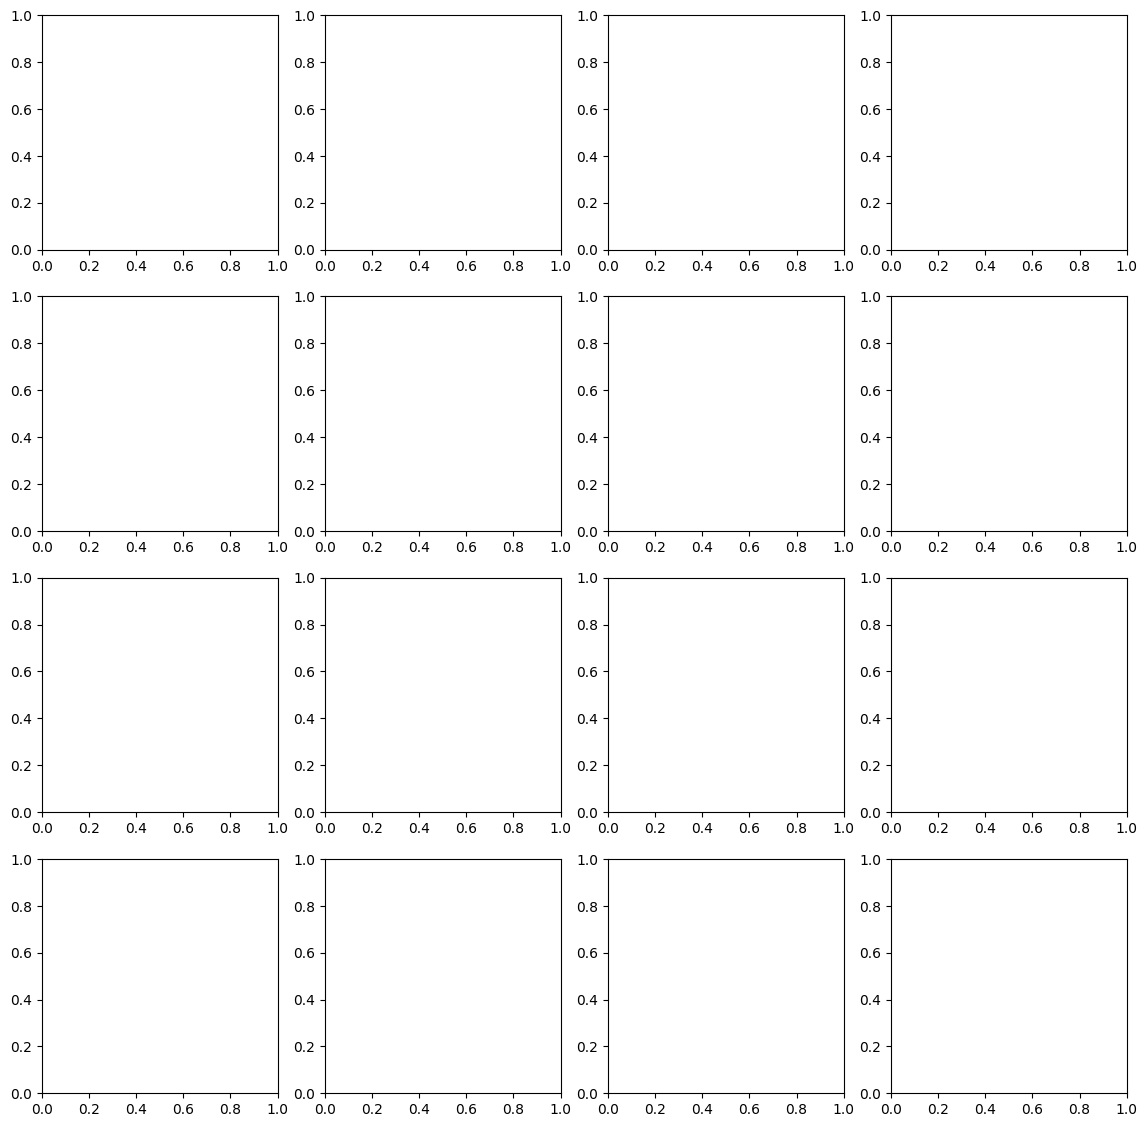

In [110]:
fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(14, 14))

plt.show()

In [111]:
print(axs)

[[<Axes: > <Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: > <Axes: >]]


In [112]:
# o output acima parece muito com um array numpy;
# vamos verificar se estamos certos.

In [113]:
print(type(axs))

<class 'numpy.ndarray'>


In [114]:
# Certo, agora que entendemos que se trata de um array numpy, precisaremos pegar as diversas dimensões (array multidimensional)
# e transformar em um de uma única dimensão (unidimensional). Esse processo nos permite aplicar um loop for em cada um dos eixos
# da figura, diminuindo assim o trabalho de plotar gráfico a gráfico. Faremos isso através de uma função interna:

In [115]:
# tornando o eixo unidimensional:
print(list(axs.flat))

[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]


In [116]:
# Agora que temos o eixo em uma única dimensão, podemos aplicar um loop for e trabalhar na plotagem gráfica em cada um dos eixos:

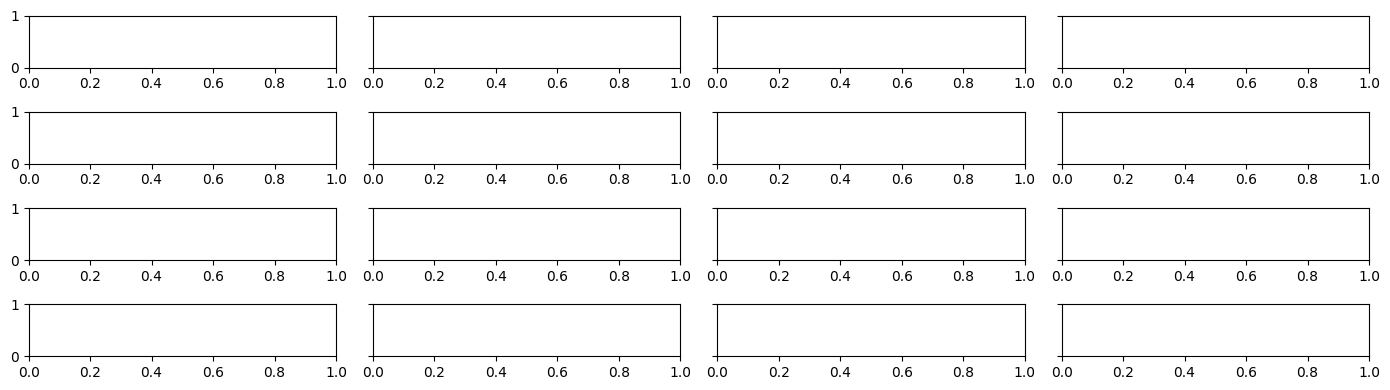

In [117]:
# Declarando a figura e seus eixos, tamanho da figura, compartilhamento do eixo y, e, um ajuste automático ente os elementos da figura (eixos, títulos, rótulos, etc) 
# com o tight_layout=True

fig, axs = plt.subplots(nrows=4, ncols= 4, figsize=(14,4), sharey=True, tight_layout=True)

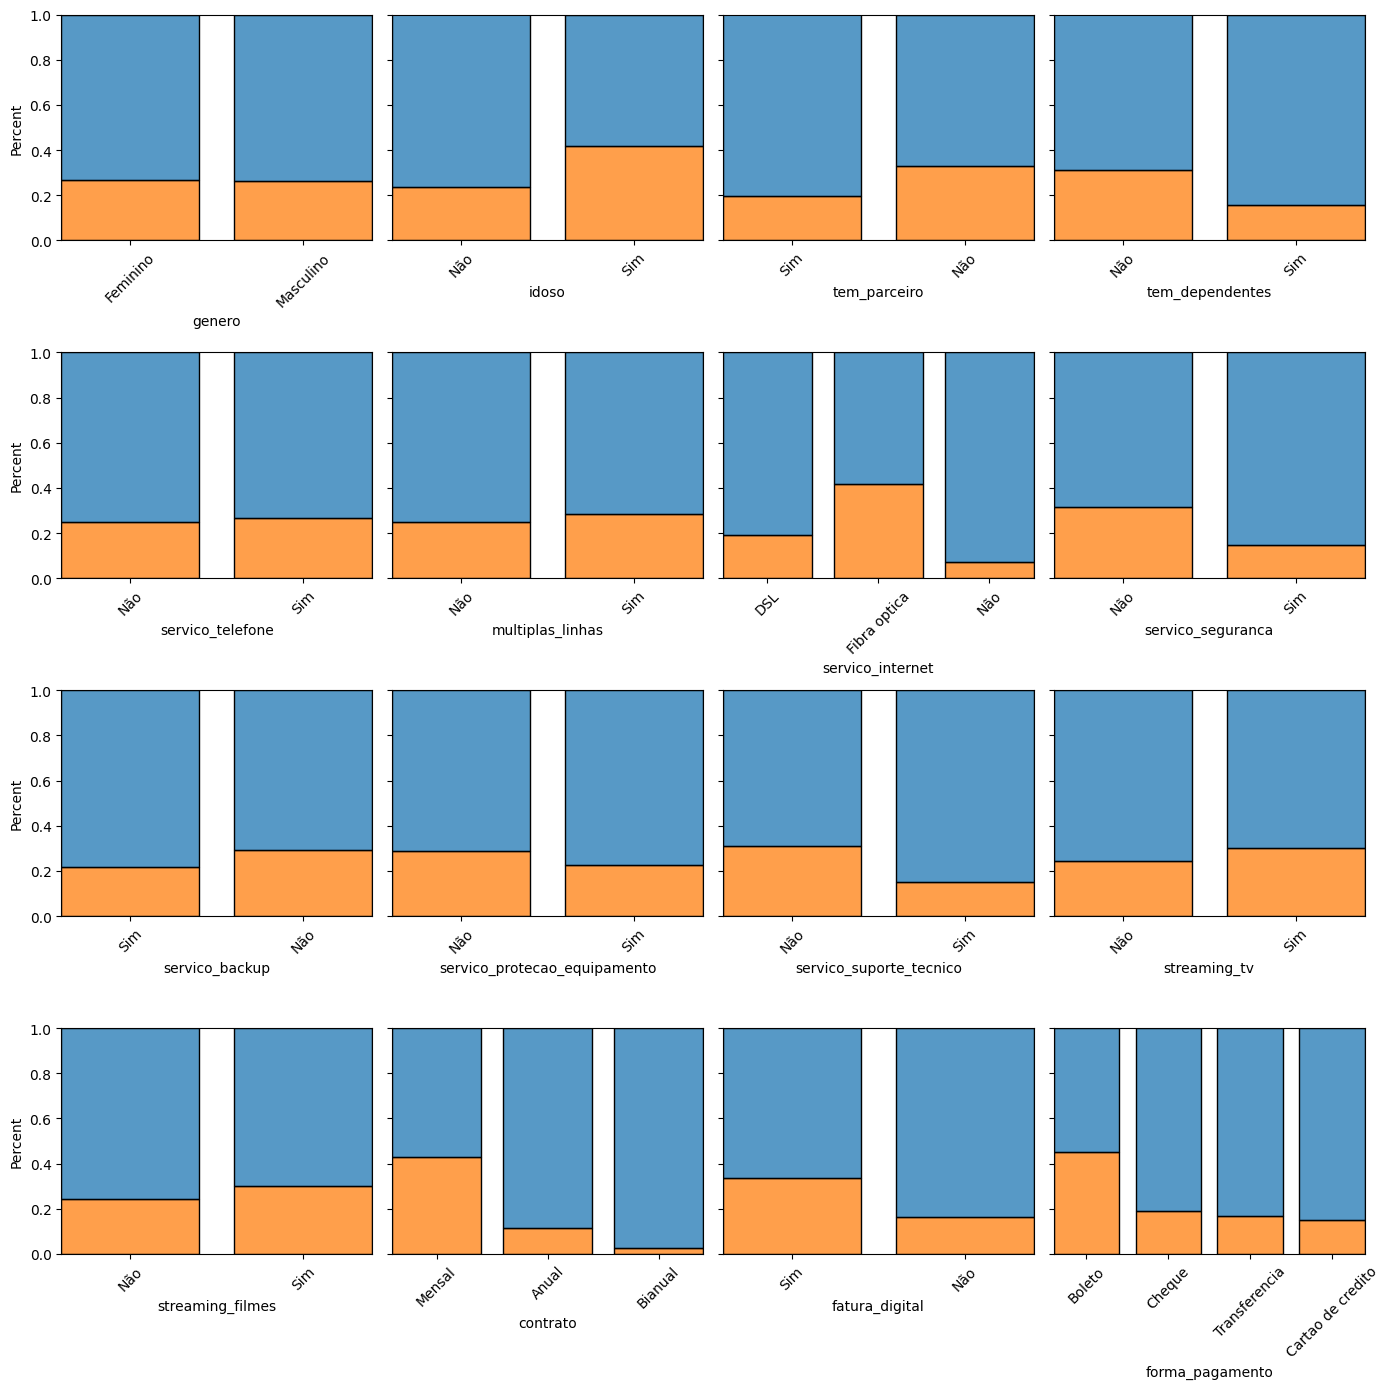

In [118]:
# agora que temos a figura, iremos realizar o loop for para aplicação da lógica e o gráficos:

# o loop percorre a lista "colunas_categorias", que contém os nomes das colunas categóricas do DataFrame df_churn. A função enumerate(), retorna:
    # i: o índice da coluna (0, 1, 2...)
    # coluna: o nome da coluna em si

#argumentos:
    # x=coluna: Eixo x é a coluna categórica atual.
    # data=df_churn: Fonte dos dados.
    # hue='churn': Divide os dados com base na coluna churn, criando barras coloridas para cada grupo (ex: churn = Sim e churn = Não).
    # multiple='fill' -> Faz com que as barras sejam empilhadas e normalizadas para 100%, mostrando proporções ao invés de contagens;
    # ax=axs.flat[i] -> Desenha o gráfico no subplot correspondente (dentro de uma grade de gráficos chamada axs).
    # stat='percent' -> mostra percentuais, não contagens absolutas.
    # shrink= 0.8 -> Diminui a largura das barras para facilitar a leitura.:


#AJUSTE FINO:
#Como o loop está criando vários gráficos, cada um geraria sua própria legenda, o que seria redundante. Aqui ele remove essas legendas individuais e reaproveita uma única legenda global.
# legenda = h.get_legend()
#legenda.remove()

#Extrai os textos da legenda removida(ex:'Sim', 'Não').
#rotulos = [text.get_text() for text in legenda.get_texts()]

fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(14, 14), sharey=True, tight_layout=True)

for i, coluna in enumerate(colunas_categoricas):
    h = sns.histplot(x= coluna, data=df_churn, hue='churn', multiple='fill', ax=axs.flat[i], stat='percent', shrink=0.8)
    h.tick_params(axis='x', labelrotation=45)
    legenda = h.get_legend()
    legenda.remove()

rotulos = [text.get_text() for text in legenda.get_texts()]

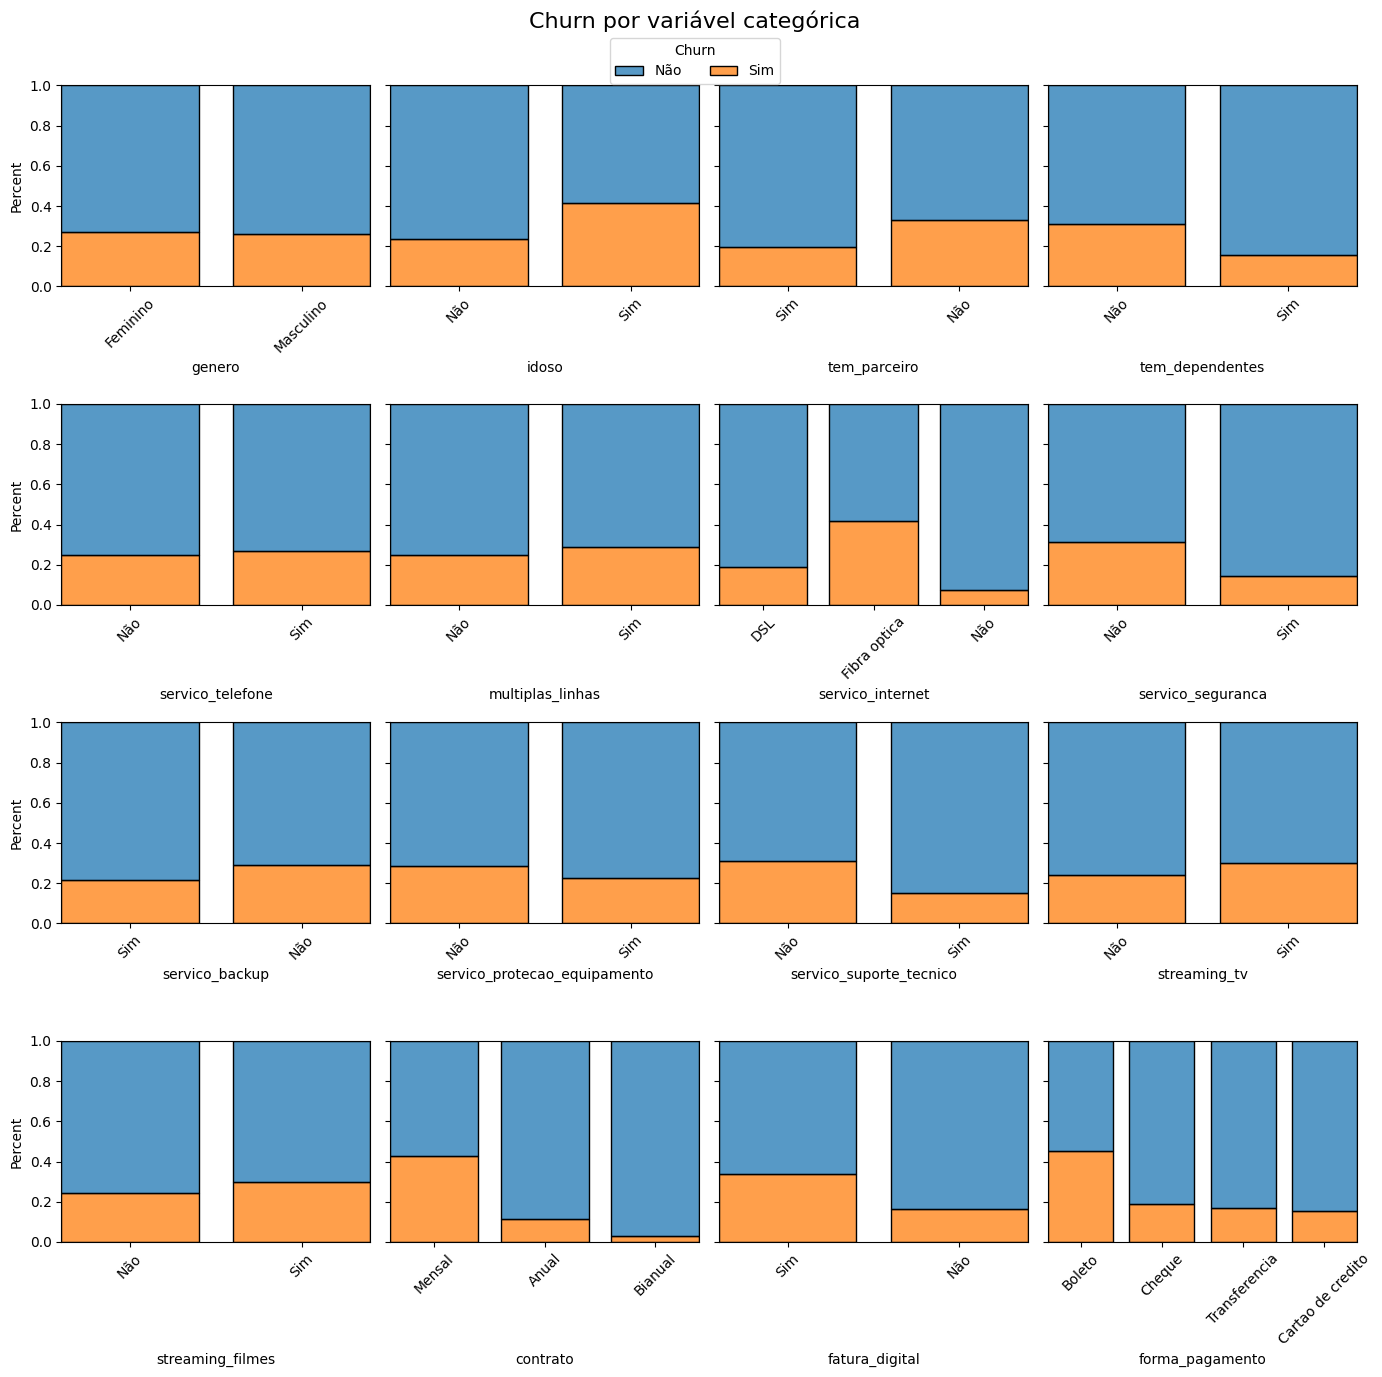

In [119]:
fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(14, 14), sharey=True, tight_layout=True)

for i, coluna in enumerate(colunas_categoricas):
    h = sns.histplot(x= coluna, data=df_churn, hue='churn', multiple='fill', ax=axs.flat[i], stat='percent', shrink=0.8)
    h.tick_params(axis='x', labelrotation=45)
    legenda = h.get_legend()
    legenda.remove()

rotulos = [text.get_text() for text in legenda.get_texts()]



#ajuste do título
fig.legend(handles=legenda.legend_handles, labels=rotulos, loc='upper center', ncols=2, title='Churn', bbox_to_anchor=(0.5, 0.965))
fig.suptitle('Churn por variável categórica\n\n', fontsize=16)

#alinhando rótulo dos eixos da figura
fig.align_labels()
plt.show()

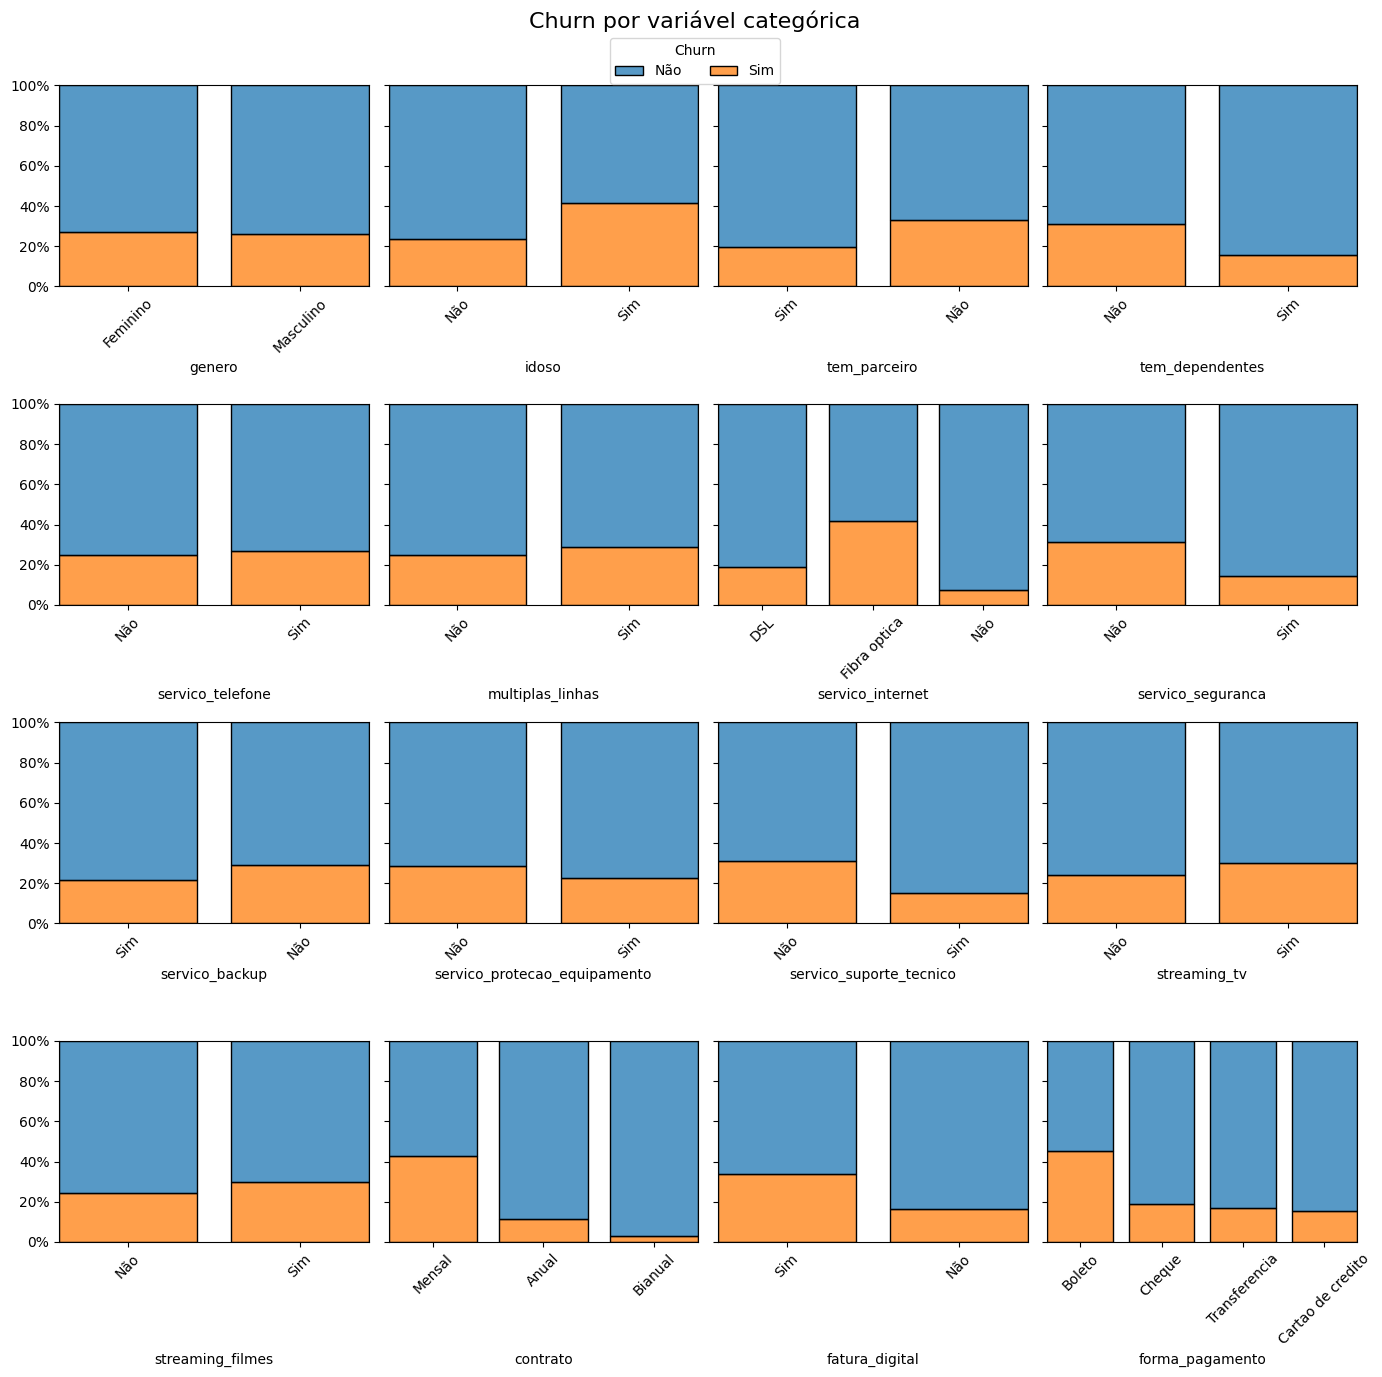

In [120]:
#funções para personalizar os tickers
from matplotlib.ticker import PercentFormatter

fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(14, 14), sharey=True, tight_layout=True)


for i, coluna in enumerate(colunas_categoricas):
    h = sns.histplot(x= coluna, data=df_churn, hue='churn', multiple='fill', ax=axs.flat[i], stat='percent', shrink=0.8)
    h.tick_params(axis='x', labelrotation=45)
    #formatando eixo y para percentual
    h.yaxis.set_major_formatter(PercentFormatter(1))
    h.set_ylabel('')

    legenda = h.get_legend()
    legenda.remove()

rotulos = [text.get_text() for text in legenda.get_texts()]

fig.legend(handles=legenda.legend_handles, labels=rotulos, loc='upper center', ncols=2, title='Churn', bbox_to_anchor=(0.5, 0.965))
fig.suptitle('Churn por variável categórica\n\n', fontsize=16)


#alinhando rótulo dos eixos da figura
fig.align_labels()

plt.show()

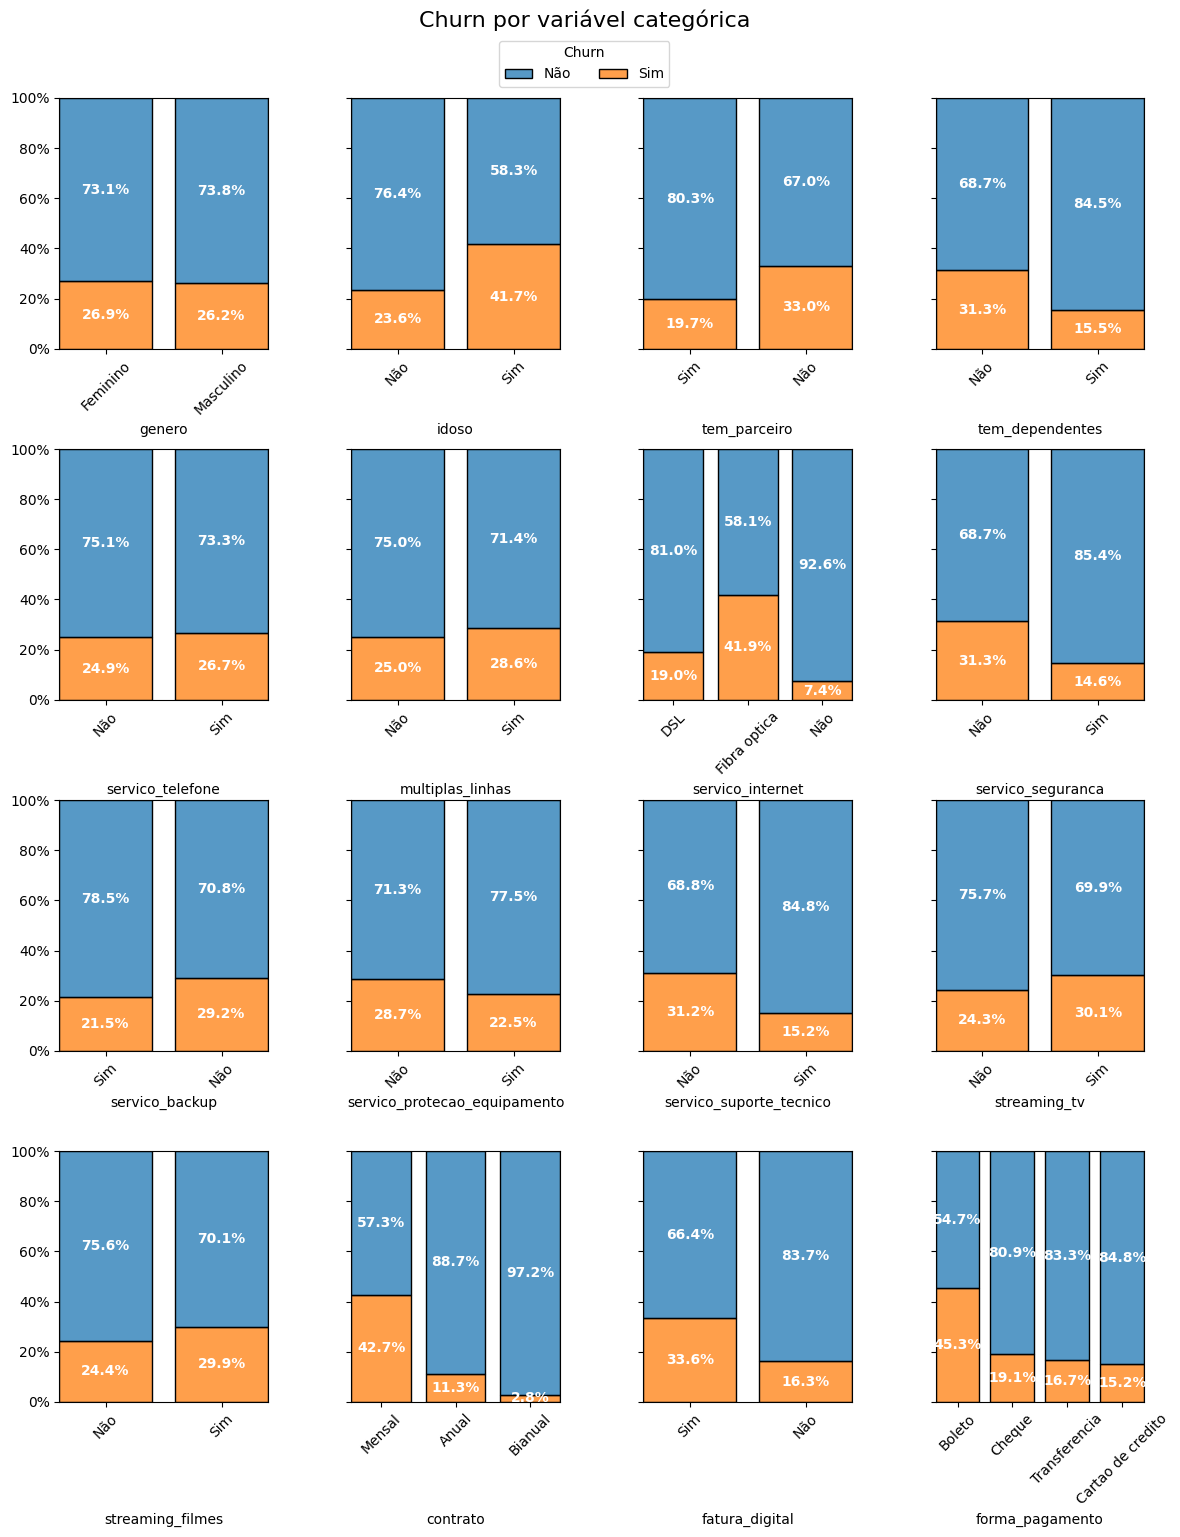

In [121]:
from matplotlib.ticker import PercentFormatter

fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(14, 16), sharey=True)


for i, coluna in enumerate(colunas_categoricas):
    h = sns.histplot(x= coluna, data=df_churn, hue='churn', multiple='fill', ax=axs.flat[i], stat='percent', shrink=0.8)
    h.tick_params(axis='x', labelrotation=45)
    #formatando eixo y para percentual
    h.yaxis.set_major_formatter(PercentFormatter(1))
    h.set_ylabel('')

    for barras in h.containers:
        h.bar_label(barras, label_type='center', labels=[f'{parte.get_height():.1%}' for parte in barras], color='white', weight='bold', fontsize=10)

    legenda = h.get_legend()
    legenda.remove()

rotulos = [text.get_text() for text in legenda.get_texts()]

fig.legend(handles=legenda.legend_handles, labels=rotulos, loc='upper center', ncols=2, title='Churn', bbox_to_anchor=(0.5, 0.965))
fig.suptitle('Churn por variável categórica', fontsize=16)


#alinhando rótulo dos eixos da figura
fig.align_labels()

#ajuste manual de espaçamento:
#wspace e hspace = ajuste de largura e altura dos eixos.
#top: é a distância do topo dos subplots até o final da figura. padrão é 0.9 (imagine que 90% da figura são os subplots e os 10% são a área do título ou restante).
plt.subplots_adjust(wspace=0.4, hspace=0.4, top=0.925)
plt.show()